In [1]:
import pandas as pd
import requests

url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

params = {
    "format": "geojson",
    "starttime": "1970-01-01",
    "minmagnitude": 4.5,
    "latitude": 8.4542,   # CDO
    "longitude": 124.6319,
    "maxradiuskm": 300
}

data = requests.get(url, params=params).json()

In [8]:
records = []

for feature in data["features"]:
    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]

    records.append({
        "time": pd.to_datetime(props["time"], unit="ms"),
        "magnitude": props["mag"],
        "place": props["place"],
        "depth_km": coords[2],
        "longitude": coords[0],
        "latitude": coords[1],
        "status": props["status"],
        "type": props["type"],
        "felt_reports": props.get("felt"),
        "tsunami": props.get("tsunami")
    })

df = pd.DataFrame(records)

df.loc[df['magnitude'] >= 7.0][["place", 'magnitude', 'longitude', 'latitude']]

,place,magnitude,longitude,latitude
193,"12 km E of Santiago, Philippines",7.40,126.6902,7.2866
963,"19 km E of Gamut, Philippines",7.60,126.4161,8.5266
2233,"4 km SE of Sagbayan, Philippines",7.10,124.1167,9.8796
2568,"72 km S of Panubigan, Philippines",7.50,123.2590,6.7760
2574,"61 km W of Bantogon, Philippines",7.60,123.4800,6.4970
2578,"68 km W of Gadung, Philippines",7.30,123.4090,6.7180
3184,"Mindanao, Philippines",7.50,124.2490,6.0330
3232,"21 km SE of Lukatan, Philippines",7.50,126.5790,6.8980
3974,"3 km E of Manay, Philippines",7.00,126.5700,7.2190
4070,"23 km ESE of Santiago, Philippines",7.30,126.7620,7.1910


In [17]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)

    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

In [19]:
CDO_LAT = 8.4542
CDO_LON = 124.6319

records.append({
    "time": pd.to_datetime(props["time"], unit="ms"),
    "magnitude": props["mag"],
    "place": props["place"],
    "depth_km": coords[2],
    "longitude": coords[0],
    "latitude": coords[1],
    "distance_km": haversine(
        CDO_LAT,
        CDO_LON,
        coords[1],
        coords[0]
    ),
    "status": props["status"],
    "type": props["type"],
    "felt_reports": props.get("felt"),
    "tsunami": props.get("tsunami")
})

In [23]:
df = pd.DataFrame(records)

df.loc[df['magnitude'] >= 7.0][["time", "place", 'magnitude', 'longitude', 'latitude', 'distance_km']]

,time,place,magnitude,longitude,latitude,distance_km
193,2025-10-10 01:43:59.585,"12 km E of Santiago, Philippines",7.40,126.6902,7.2866,NaN
963,2023-12-02 14:37:04.454,"19 km E of Gamut, Philippines",7.60,126.4161,8.5266,NaN
2233,2013-10-15 00:12:32.050,"4 km SE of Sagbayan, Philippines",7.10,124.1167,9.8796,NaN
2568,2010-07-23 23:15:10.190,"72 km S of Panubigan, Philippines",7.50,123.2590,6.7760,NaN
2574,2010-07-23 22:51:11.840,"61 km W of Bantogon, Philippines",7.60,123.4800,6.4970,NaN
2578,2010-07-23 22:08:11.250,"68 km W of Gadung, Philippines",7.30,123.4090,6.7180,NaN
3184,2002-03-05 21:16:09.130,"Mindanao, Philippines",7.50,124.2490,6.0330,NaN
3232,2001-01-01 06:57:04.170,"21 km SE of Lukatan, Philippines",7.50,126.5790,6.8980,NaN
3974,1993-05-11 18:26:51.320,"3 km E of Manay, Philippines",7.00,126.5700,7.2190,NaN
4070,1992-05-17 10:15:31.310,"23 km ESE of Santiago, Philippines",7.30,126.7620,7.1910,NaN


In [24]:
df.columns

Index(['time', 'magnitude', 'place', 'depth_km', 'longitude', 'latitude',
       'status', 'type', 'felt_reports', 'tsunami', 'distance_km'],
      dtype='object')

In [25]:
df["distance_km"].isna().sum()

np.int64(5464)

In [26]:
df["distance_km"].describe()

count      1.000000
mean     287.707963
std             NaN
min      287.707963
25%      287.707963
50%      287.707963
75%      287.707963
max      287.707963
Name: distance_km, dtype: float64

In [27]:
m4 = df[df["magnitude"] >= 4.5].copy()
m5 = df[df["magnitude"] >= 5.0].copy()
m6 = df[df["magnitude"] >= 6.0].copy()
m7 = df[df["magnitude"] >= 7.0].copy()

In [28]:
df["distance_bin"] = pd.cut(
    df["distance_km"],
    bins=[0, 50, 100, 200, 300, 1000],
    labels=["0–50", "50–100", "100–200", "200–300", "300+"]
)

In [29]:
freq = pd.DataFrame({
    "M≥4.5": [len(m4)],
    "M≥5.0": [len(m5)],
    "M≥6.0": [len(m6)],
    "M≥7.0": [len(m7)],
})
freq

,M≥4.5,M≥5.0,M≥6.0,M≥7.0
0,5465,1643,116,17


In [30]:
zone_counts = df.groupby("distance_bin").size()
zone_counts

C:\Users\loydt\AppData\Local\Temp\ipykernel_23204\1988989506.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_counts = df.groupby("distance_bin").size()


distance_bin
0–50       0
50–100     0
100–200    0
200–300    1
300+       0
dtype: int64

In [32]:
monthly_m4 = m4.set_index("time").resample("ME").size()
monthly_m5 = m5.set_index("time").resample("ME").size()
monthly_m6 = m6.set_index("time").resample("ME").size()

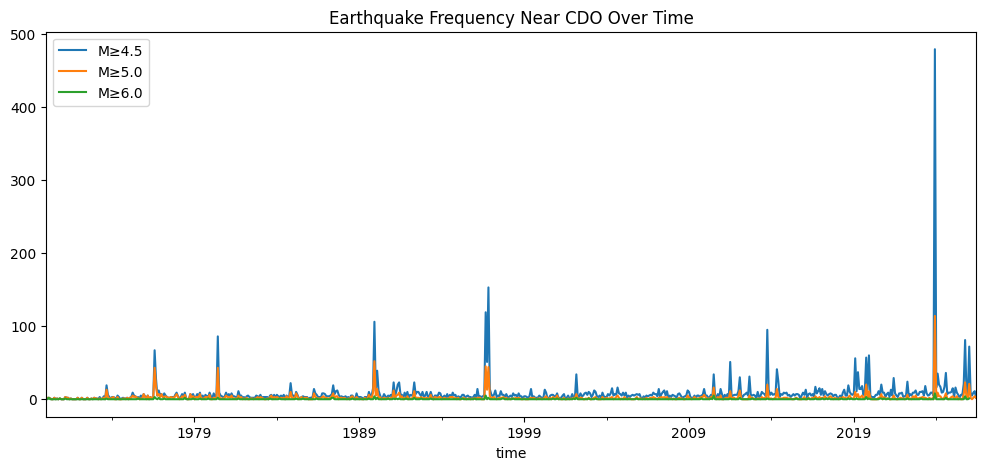

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
monthly_m4.plot(label="M≥4.5")
monthly_m5.plot(label="M≥5.0")
monthly_m6.plot(label="M≥6.0")

plt.legend()
plt.title("Earthquake Frequency Near CDO Over Time")
plt.show()

In [34]:
import folium

# filter M7+
df7 = df.loc[df["magnitude"] >= 7.0][
    ["time", "place", 'magnitude', 'longitude', 'latitude', 'distance_km']
].dropna()

# center map (Cagayan de Oro)
m = folium.Map(location=[8.4542, 124.6319], zoom_start=6)

# add points
for _, row in df7.iterrows(): 
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8,
        popup=f"{row['place']} | M{row['magnitude']}",
        color="red",
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

from IPython.display import display

m.save(r"C:\Users\loydt\Downloads\earthquake_map.html")